In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv("global_tech_startups_2026.csv")

print(df.head())
print(df.shape)

  Company_ID         Domain  Founding_Year Country           City  \
0   B730AD52     HealthTech           2014  Canada       Montreal   
1   65A5F690    Web3/Crypto           2014   China        Beijing   
2   F106C853  Cybersecurity           2020     USA  San Francisco   
3   2BD798AF        FinTech           2023   India      Delhi NCR   
4   C5CB4451  Generative AI           2020     USA       New York   

  Funding_Stage  Total_Funding_USD_Millions  Valuation_USD_Millions  \
0          Seed                        1.64                   17.81   
1       Pre-IPO                      103.87                  949.16   
2      Series A                       10.08                   43.37   
3      Series B                       32.28                  257.62   
4     Series C+                       13.41                   76.73   

   Revenue_ARR_Millions  Monthly_Burn_Rate_Millions  Runway_Months_2024  \
0                  1.46                        0.33                 3.8   
1       

In [4]:
y = df["Valuation_USD_Millions"]

X = df[
    [
        "Total_Funding_USD_Millions",
        "Revenue_ARR_Millions",
        "Current_Headcount_2026"
    ]
]

X = sm.add_constant(X)

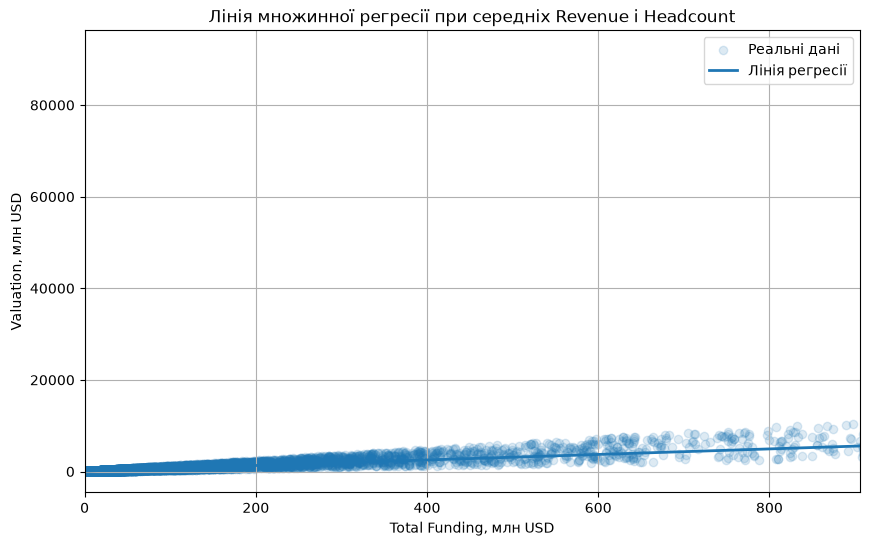

In [7]:
#середні значення інших факторів
mean_revenue = df["Revenue_ARR_Millions"].mean()
mean_headcount = df["Current_Headcount_2026"].mean()

#діапазон Funding для лінії
funding_range = np.linspace(
    df["Total_Funding_USD_Millions"].min(),
    df["Total_Funding_USD_Millions"].quantile(0.99),
    200
)

#обчислюю прогнозовану Valuation
regression_line = (
    model.params["const"]
    + model.params["Total_Funding_USD_Millions"] * funding_range
    + model.params["Revenue_ARR_Millions"] * mean_revenue
    + model.params["Current_Headcount_2026"] * mean_headcount
)

#графік
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Total_Funding_USD_Millions"],
    df["Valuation_USD_Millions"],
    alpha=0.15,
    label="Реальні дані"
)

plt.plot(
    funding_range,
    regression_line,
    linewidth=2,
    label="Лінія регресії"
)

plt.xlabel("Total Funding, млн USD")
plt.ylabel("Valuation, млн USD")
plt.title("Лінія множинної регресії при середніх Revenue і Headcount")

plt.legend()
plt.grid()
plt.xlim(
    0,
    df["Total_Funding_USD_Millions"].quantile(0.99)
)

plt.show()

In [5]:
model = sm.OLS(y, X).fit()

print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     Valuation_USD_Millions   R-squared:                       0.922
Model:                                OLS   Adj. R-squared:                  0.922
Method:                     Least Squares   F-statistic:                 9.845e+04
Date:                    Fri, 09 Oct 2026   Prob (F-statistic):               0.00
Time:                            01:37:17   Log-Likelihood:            -1.9067e+05
No. Observations:                   25000   AIC:                         3.813e+05
Df Residuals:                       24996   BIC:                         3.814e+05
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [15]:
predicted = model.predict(X)
residuals = y - predicted

n = len(y)
p = 3

RSS = np.sum(residuals ** 2)
RMSE = np.sqrt(RSS / n)
RSE = np.sqrt(RSS / (n - p - 1))

TSS = np.sum((y - y.mean()) ** 2)
R2 = 1 - RSS / TSS

t_b = model.tvalues

print("RSS =", RSS)
print("RMSE =", RMSE)
print("RSE =", RSE)
print("R^2 =", R2)
print("t_b =")
print(t_b)

RSS = 6165860686.240586
RMSE = 496.62302347920144
RSE = 496.6627580892966
R^2 = 0.9219717513927216
t_b =
const                          -4.393379
Total_Funding_USD_Millions    118.544979
Revenue_ARR_Millions           95.810316
Current_Headcount_2026         -4.894212
dtype: float64


In [16]:
future = pd.DataFrame({
    "Total_Funding_USD_Millions": [123.4520, 257.6075, 905.3661],
    "Revenue_ARR_Millions": [62.9620, 135.2510, 502.2507],
    "Current_Headcount_2026": [355, 707.1, 2516.04]
})

future_X = sm.add_constant(
    future,
    has_constant="add"
)

forecast = model.get_prediction(
    future_X
).summary_frame(alpha=0.05)

forecast_result = pd.concat(
    [future, forecast],
    axis=1
)

print(forecast_result)

   Total_Funding_USD_Millions  Revenue_ARR_Millions  Current_Headcount_2026  \
0                    123.4520               62.9620                  355.00   
1                    257.6075              135.2510                  707.10   
2                    905.3661              502.2507                 2516.04   

          mean    mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0   953.838105   3.294250     947.381181     960.295030    -19.671565   
1  2023.910926   4.350954    2015.382799    2032.439053   1050.385315   
2  7253.767782  13.115891    7228.059863    7279.475700   6279.940136   

   obs_ci_upper  
0   1927.347776  
1   2997.436537  
2   8227.595427  


In [17]:
from sklearn.metrics import mean_squared_error

RMSE_python = np.sqrt(
    mean_squared_error(y, predicted)
)

print("RMSE за формулою =", RMSE)
print("RMSE Python =", RMSE_python)

RMSE за формулою = 496.62302347920144
RMSE Python = 496.62302347920144


In [18]:
print("R^2 за формулою =", R2)
print("R^2 Python =", model.rsquared)

R^2 за формулою = 0.9219717513927216
R^2 Python = 0.9219717513927216


In [19]:
b = model.params["Total_Funding_USD_Millions"]
SE_b = model.bse["Total_Funding_USD_Millions"]

t_manual = b / SE_b
t_python = model.tvalues["Total_Funding_USD_Millions"]

print("t_b за формулою =", t_manual)
print("t_b Python =", t_python)

t_b за формулою = 118.54497873753586
t_b Python = 118.54497873753586


In [20]:
print(df["Funding_Stage"].unique())
print("Кількість рівнів:", df["Funding_Stage"].nunique())

<StringArray>
['Seed', 'Pre-IPO', 'Series A', 'Series B', 'Series C+', 'Post-IPO']
Length: 6, dtype: str
Кількість рівнів: 6


In [21]:
reference_encoding = pd.get_dummies(
    df["Funding_Stage"],
    prefix="Stage",
    dtype=int
)

reference_encoding = reference_encoding.drop(
    columns=["Stage_Seed"]
)

print(reference_encoding.head(10))

   Stage_Post-IPO  Stage_Pre-IPO  Stage_Series A  Stage_Series B  \
0               0              0               0               0   
1               0              1               0               0   
2               0              0               1               0   
3               0              0               0               1   
4               0              0               0               0   
5               0              0               1               0   
6               0              0               1               0   
7               0              0               0               0   
8               0              0               0               0   
9               0              0               0               1   

   Stage_Series C+  
0                0  
1                0  
2                0  
3                0  
4                1  
5                0  
6                0  
7                0  
8                1  
9                0  


In [23]:
one_hot_encoding = pd.get_dummies(
    df["Funding_Stage"],
    prefix="Stage",
    dtype=int,
    drop_first=False
)

print(one_hot_encoding.head(10))

   Stage_Post-IPO  Stage_Pre-IPO  Stage_Seed  Stage_Series A  Stage_Series B  \
0               0              0           1               0               0   
1               0              1           0               0               0   
2               0              0           0               1               0   
3               0              0           0               0               1   
4               0              0           0               0               0   
5               0              0           0               1               0   
6               0              0           0               1               0   
7               0              0           1               0               0   
8               0              0           0               0               0   
9               0              0           0               0               1   

   Stage_Series C+  
0                0  
1                0  
2                0  
3                0  
4             

In [24]:
predictors = df[
    [
        "Total_Funding_USD_Millions",
        "Revenue_ARR_Millions",
        "Current_Headcount_2026"
    ]
]

print(predictors.corr())

                            Total_Funding_USD_Millions  Revenue_ARR_Millions  \
Total_Funding_USD_Millions                    1.000000              0.838582   
Revenue_ARR_Millions                          0.838582              1.000000   
Current_Headcount_2026                        0.941367              0.783495   

                            Current_Headcount_2026  
Total_Funding_USD_Millions                0.941367  
Revenue_ARR_Millions                      0.783495  
Current_Headcount_2026                    1.000000  


In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(predictors)

vif_table = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

print(vif_table)

                     Variable        VIF
0                       const   1.000000
1  Total_Funding_USD_Millions  11.442126
2        Revenue_ARR_Millions   3.372997
3      Current_Headcount_2026   8.794308


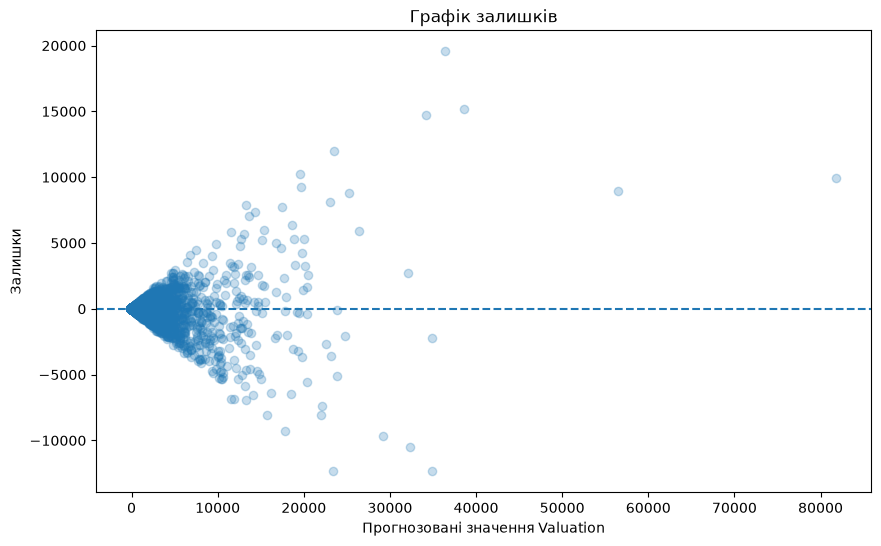

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(
    predicted,
    residuals,
    alpha=0.25
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Прогнозовані значення Valuation")
plt.ylabel("Залишки")
plt.title("Графік залишків")

plt.show()

In [27]:
columns = [
    "Total_Funding_USD_Millions",
    "Revenue_ARR_Millions",
    "Current_Headcount_2026"
]

for column in columns:
    print(
        column,
        "min =", df[column].min(),
        "max =", df[column].max()
    )

Total_Funding_USD_Millions min = 0.0 max = 7867.39
Revenue_ARR_Millions min = 0.05 max = 9021.53
Current_Headcount_2026 min = 0 max = 25657


In [28]:
extra = pd.DataFrame({
    "Total_Funding_USD_Millions": [
        df["Total_Funding_USD_Millions"].max() * 1.10
    ],
    
    "Revenue_ARR_Millions": [
        df["Revenue_ARR_Millions"].max() * 1.10
    ],
    
    "Current_Headcount_2026": [
        df["Current_Headcount_2026"].max() * 1.10
    ]
})

In [29]:
for column in columns:
    
    min_value = df[column].min()
    max_value = df[column].max()
    new_value = extra[column].iloc[0]

    if new_value < min_value or new_value > max_value:
        print(column, "-> ЕКСТРАПОЛЯЦІЯ")
    else:
        print(column, "-> в межах даних")

Total_Funding_USD_Millions -> ЕКСТРАПОЛЯЦІЯ
Revenue_ARR_Millions -> ЕКСТРАПОЛЯЦІЯ
Current_Headcount_2026 -> ЕКСТРАПОЛЯЦІЯ


In [30]:
extra_X = sm.add_constant(
    extra,
    has_constant="add"
)

extra_prediction = model.predict(extra_X)

print(
    "Прогноз регресії =",
    extra_prediction.iloc[0]
)

Прогноз регресії = 89481.47899420926
